# From ObsPy to a moment tensor and back

This notebook inverts the 2019-07-04 Ridgecrest foreshock (Mw 6.4, 17:33:49 UTC) for its moment tensor without
leaving ObsPy. FDSN web services give the catalogue `Event`, the station `Inventory` and the waveform `Stream`.
The library turns them into a data vector and a noise covariance, fits a moment tensor, and hands back the
synthetics as a `Stream` and the posterior as a QuakeML `Event`. No configuration file, station file or HDF5
file is written by hand.

With `ONLINE = False` the notebook reads the same data from `data/ridgecrest/` (its README lists the calls), so
it runs offline. Set it to `True` to download the data afresh. The forward model is an Instaseis database that
resolves 20 s periods, such as `prem_a_20s`.

In [1]:
import os
from pathlib import Path

from obspy import UTCDateTime

ONLINE = False
DATA = Path("data/ridgecrest")
DATABASE = os.environ.get("INSTASEIS_DB_20S", "/data/shared/prem_a_20s")
ORIGIN_TIME = UTCDateTime("2019-07-04T17:33:49")
BAND_HZ = (0.02, 0.05)
SAMPLING_RATE_HZ = 0.5

## The event and its published moment tensors

The USGS event carries the USGS (Mww, Mwb) and Southern California Seismic Network tensors. The ISC event adds
GCMT and GFZ, each with the centroid it was derived at. The next cell loads both events, or reads them from
disk, and lists each tensor once: tensors that ISC copies from the USGS are not repeated. Mw is computed from
each tensor's scalar moment.

In [2]:
import numpy as np
from obspy import read_events
from obspy.clients.fdsn import Client

from seismo_sbi.moment_tensor.conventions import moment_magnitude
from seismo_sbi.moment_tensor.quakeml import moment_tensor_from_tensor

if ONLINE:
    catalogue = Client("USGS").get_events(eventid="ci38443183", includeallorigins=True, includeallmagnitudes=True)
    catalogue += Client("ISC").get_events(starttime=ORIGIN_TIME - 60, endtime=ORIGIN_TIME + 60, minmagnitude=6,
                                          includeallorigins=True, includeallmagnitudes=True)
else:
    catalogue = read_events(DATA / "events.xml.gz")
hypocentre = catalogue[0].preferred_origin()
AGENCIES = {"us": "USGS", "CI": "SCSN"}

published, centroids = {}, {}
for mechanism in (mechanism for event in catalogue for mechanism in event.focal_mechanisms):
    if mechanism.moment_tensor is None or mechanism.moment_tensor.tensor is None:
        continue
    m6 = moment_tensor_from_tensor(mechanism.moment_tensor.tensor)
    agency = AGENCIES.get(mechanism.creation_info.agency_id, mechanism.creation_info.author)
    if any(np.allclose(m6, other, rtol=1e-3) for other in published.values()):
        continue
    label = f"{agency} Mw {moment_magnitude(m6):.2f}"
    published[label] = m6
    if mechanism.moment_tensor.derived_origin_id is not None:
        centroids[label] = mechanism.moment_tensor.derived_origin_id.get_referred_object()

print(f"hypocentre {hypocentre.latitude:.3f} N {-hypocentre.longitude:.3f} W, depth {hypocentre.depth / 1e3:.1f} km")
for label in published:
    centroid = centroids.get(label)
    where = (f"centroid depth {centroid.depth / 1e3:4.1f} km, {centroid.time - hypocentre.time:4.1f} s after the hypocentre"
             if centroid is not None else "")
    print(f"{label:16s} {where}")

hypocentre 35.705 N 117.504 W, depth 10.5 km
SCSN Mw 6.39     
USGS Mw 6.47     
USGS Mw 6.32     
GCMT Mw 6.45     centroid depth 12.7 km,  9.4 s after the hypocentre
GFZ Mw 6.41      centroid depth 12.0 km,  2.0 s after the hypocentre


## Stations and waveforms

Eight broadband stations 2 to 4 degrees from the epicentre (at least ten rupture lengths) were chosen for a high
signal-to-noise ratio at 20-50 s, no clipping, and azimuthal coverage with no gap above 66 degrees. Each network
is served by its own data centre. The rupture is about 15-20 km long and lasts about 8 s. At 20-50 s the
wavelengths are 70 km and more, and the periods are several source durations, so a point source at the centroid
describes the waves. The next cell downloads, or reads, the waveforms and the `Inventory`, and builds the
`Receivers` from the `Inventory`.

In [3]:
from obspy import Inventory, Stream, read, read_inventory
from obspy.geodetics import gps2dist_azimuth

from seismo_sbi.simulators.receivers import Receivers

STATIONS = {"SCEDC": [("CI", "PDM", "", "BH?"), ("CI", "SCI2", "", "BH?"), ("CI", "SMR", "", "BH?")],
            "NCEDC": [("BK", "PACP", "00", "BH?"), ("BK", "WELL", "00", "BH?")],
            "EARTHSCOPE": [("NN", "Q09A", "", "HH?"), ("NN", "SHP", "", "HH?"), ("PY", "BPH05", "", "BH?")]}
if ONLINE:
    raw, inventory = Stream(), Inventory()
    for centre, codes in STATIONS.items():
        client = Client(centre)
        for network, station, location, channel in codes:
            raw += client.get_waveforms(network, station, location, channel, ORIGIN_TIME - 1500, ORIGIN_TIME + 500)
            inventory += client.get_stations(network=network, station=station, location=location, channel=channel,
                                             starttime=ORIGIN_TIME - 1500, endtime=ORIGIN_TIME + 500, level="response")
    raw.merge(method=0).detrend("linear").resample(1.0)
else:
    raw, inventory = read(DATA / "waveforms.mseed"), read_inventory(DATA / "stations.xml.gz")

receivers = Receivers.from_inventory(inventory)
geometry = {receiver.station_name: gps2dist_azimuth(hypocentre.latitude, hypocentre.longitude, receiver.latitude,
                                                    receiver.longitude)[:2] for receiver in receivers}
for receiver in receivers:
    distance_m, azimuth_deg = geometry[receiver.station_name]
    print(f"{receiver.network}.{receiver.station_name:6s} {distance_m / 111.19e3:4.2f} deg  azimuth {azimuth_deg:5.1f} deg")

CI.PDM    3.09 deg  azimuth 115.9 deg
CI.SCI2   2.85 deg  azimuth 197.9 deg
CI.SMR    2.56 deg  azimuth 263.5 deg
BK.PACP   3.32 deg  azimuth 294.2 deg
BK.WELL   3.75 deg  azimuth 317.6 deg
NN.Q09A   3.13 deg  azimuth   4.6 deg
NN.SHP    2.06 deg  azimuth  66.5 deg
PY.BPH05  2.26 deg  azimuth 157.2 deg


The stations (triangles) around the epicentre (star), and the five published tensors as beachballs.
The eight stations surround the epicentre at 2-4 degrees. Four of the
five published tensors are near-vertical strike-slip mechanisms with the same nodal planes, and the SCSN tensor,
with a shallower dip, stands apart.

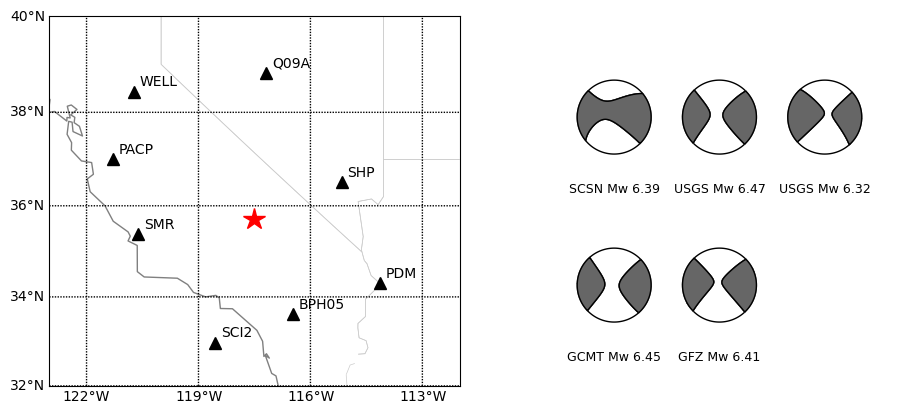

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

from seismo_sbi.moment_tensor.comparison import pyrocko_mt
from seismo_sbi.plotting.rocko_beachball_patch import plot_beachball_on_axes

fig, (ax_map, ax_balls) = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw=dict(width_ratios=[1.3, 1]))
region = Basemap(projection="merc", llcrnrlat=32, urcrnrlat=40, llcrnrlon=-123, urcrnrlon=-112, resolution="l", ax=ax_map)
region.drawcoastlines(color="0.5")
region.drawstates(color="0.8")
region.drawparallels(range(32, 41, 2), labels=[1, 0, 0, 0]), region.drawmeridians(range(-122, -111, 3), labels=[0, 0, 0, 1])
for receiver in receivers:
    x, y = region(receiver.longitude, receiver.latitude)
    ax_map.plot(x, y, "k^", ms=8), ax_map.annotate(receiver.station_name, (x, y), xytext=(4, 4), textcoords="offset points")
ax_map.plot(*region(hypocentre.longitude, hypocentre.latitude), "r*", ms=16)
ax_balls.set(xlim=(-0.6, 2.6), ylim=(-1.6, 0.6)), ax_balls.axis("off")
for k, (label, m6) in enumerate(published.items()):
    plot_beachball_on_axes(ax_balls, pyrocko_mt(m6), k % 3, -(k // 3), diameter=0.2, linewidth=1, color_t="0.4")
    ax_balls.text(k % 3, -(k // 3) - 0.45, label, ha="center", fontsize=9)
plt.show()

## The observation and its noise covariance from the `Stream`

The next cell processes the `Stream`. The instrument response is removed to displacement, the horizontals are
rotated to north and east, and the traces are band-passed at 20-50 s and resampled to 0.5 Hz. The event window
starts 60 s before the origin time, as the Instaseis synthetics do, and runs for 350 s. `observation_from_stream`
turns the window into the data vector and the station presence mask. The noise covariance comes from the 1200 s
before the window, through `pre_event_autocorrelations`.

In [5]:
from seismo_sbi.data_handling.preprocessing.processing import deconvolve_and_filter
from seismo_sbi.data_handling.preprocessing.sbi_export import observation_from_stream, pre_event_autocorrelations
from seismo_sbi.sbi.noises.toeplitz_covariances import BlockDiagonalEmpiricalCovariance

processed = deconvolve_and_filter(raw, inventory, filter_kwargs=dict(freqmin=BAND_HZ[0], freqmax=BAND_HZ[1]),
                                  target_sr=SAMPLING_RATE_HZ)
window = (ORIGIN_TIME - 60, ORIGIN_TIME + 290)
observed, present = observation_from_stream(processed, receivers, window, SAMPLING_RATE_HZ)
n_samples = observed.size // (3 * len(receivers))
noise = pre_event_autocorrelations(processed, [receiver.station_name for receiver in receivers], window[0], 1200.0)
noise_covariance = BlockDiagonalEmpiricalCovariance(noise, receivers, n_samples, num_jobs=1)
print(f"{present.sum()} of {len(receivers)} stations present, {observed.size} samples "
      f"({n_samples} per trace), peak displacement {np.abs(observed).max() * 1e3:.2f} mm")

8 of 8 stations present, 4224 samples (176 per trace), peak displacement 2.29 mm


Left, the vertical traces with the noise window (grey, the 1200 s before the event window) and the event window
(blue). Right, each station's vertical noise autocovariance against lag, the first column of its covariance block.
The waves stand far above the pre-event noise on every trace. The noise
autocovariance falls to zero within about 8 s and rings at periods of 20-40 s, the pass band, so neighbouring
samples are correlated and each covariance block is far from diagonal. SCI2 and WELL are the noisiest stations.

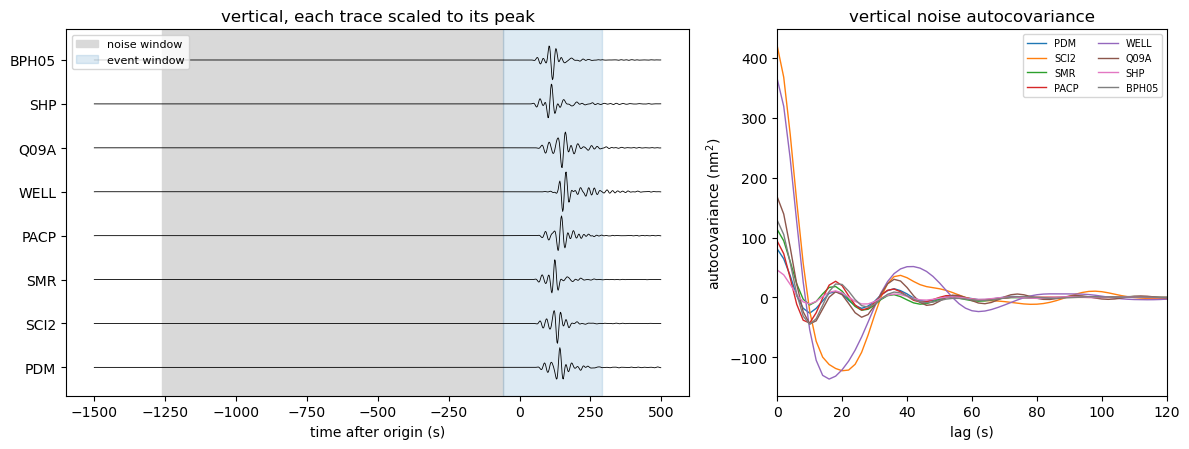

In [6]:
fig, (ax_traces, ax_lags) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw=dict(width_ratios=[1.6, 1]))
for row, receiver in enumerate(receivers):
    trace = processed.select(station=receiver.station_name, component="Z")[0]
    time_s = trace.times() + (trace.stats.starttime - ORIGIN_TIME)
    ax_traces.plot(time_s, row + 0.45 * trace.data / np.abs(trace.data).max(), "k", lw=0.6)
    autocovariance = noise[receiver.station_name]["Z"]
    ax_lags.plot(np.arange(len(autocovariance)) / SAMPLING_RATE_HZ, autocovariance * 1e18, lw=1.0,
                 label=receiver.station_name)
ax_traces.axvspan(-60 - 1200, -60, color="0.85", zorder=0, label="noise window")
ax_traces.axvspan(-60, 290, color="C0", alpha=0.15, zorder=0, label="event window")
ax_traces.set(yticks=range(len(receivers)), yticklabels=[receiver.station_name for receiver in receivers],
              xlabel="time after origin (s)", title="vertical, each trace scaled to its peak")
ax_traces.legend(loc="upper left", fontsize=8)
ax_lags.set(xlim=(0, 120), xlabel="lag (s)", ylabel="autocovariance (nm$^2$)", title="vertical noise autocovariance")
ax_lags.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

## Least squares at the hypocentre and at the centroid

The seismograms are linear in the six moment-tensor components, so six simulations give the kernels, and the
least-squares tensor follows directly. Waves at 20-50 s see the centroid: GCMT puts it 12.7 km deep and 9.4 s
after the hypocentral origin time, which is half a cycle at 20 s. Only GCMT's centroid position and time are
borrowed. The mechanism is fitted independently. The next cell builds the simulator, computes the kernels at
the hypocentre and at the centroid, and prints the least-squares tensor and its fit at each.

In [7]:
from seismo_sbi.moment_tensor.quakeml import source_location_from_origin
from seismo_sbi.simulators.instaseis.simulator import InstaseisSourceSimulator
from seismo_sbi.simulators.simulation_io import seismogram_map_to_array

simulator = InstaseisSourceSimulator(
    DATABASE, components="ZEN", receivers=receivers, seismogram_duration_in_s=350.0,
    synthetics_processing={"filter": {"type": "bandpass", "freqmin": BAND_HZ[0], "freqmax": BAND_HZ[1],
                                      "corners": 4, "zerophase": False},
                           "sampling_rate": SAMPLING_RATE_HZ, "filter_sampling_rate": 1.0})


def kernels_at(source):
    """``(6, n_data)`` synthetics of the six unit moment tensors at ``source``."""
    return np.array([seismogram_map_to_array(simulator.run_simulation(
        {"source_location": list(source), "moment_tensor": list(unit)})[1], receivers) for unit in np.eye(6)])


sources = {"hypocentre": source_location_from_origin(hypocentre),
           "GCMT centroid": source_location_from_origin(centroids[next(l for l in centroids if l.startswith("GCMT"))],
                                                        origin_time_utc=hypocentre.time)}
kernels = {name: kernels_at(source) for name, source in sources.items()}
for name, source in sources.items():
    least_squares, *_ = np.linalg.lstsq(kernels[name].T, observed, rcond=None)
    reduction = 1 - np.sum((observed - kernels[name].T @ least_squares) ** 2) / np.sum(observed ** 2)
    print(f"{name:14s} depth {source.depth:4.1f} km, {source.time_shift:4.1f} s: variance reduction {reduction:.2f}, "
          f"Mw {moment_magnitude(least_squares):.2f}")

hypocentre     depth 10.5 km,  0.0 s: variance reduction 0.19, Mw 6.11
GCMT centroid  depth 12.7 km,  9.4 s: variance reduction 0.59, Mw 6.28


## The Gaussian-likelihood posterior

Score compression with the empirical noise covariance gives the Gaussian-likelihood posterior in closed form.
Its mean is the weighted least-squares tensor, and its covariance is the inverse Fisher matrix. The covariance
describes the pre-event noise alone. The next cell builds the compressor at the GCMT centroid and draws 4000
samples from that posterior. It also prints $\chi^2/N \approx 10^7$: the residual is about ten million times
what that noise can explain. The misfit is modelling error, here 1-D PREM at 2-4 degrees and 20-50 s, which the
noise covariance does not describe. The width of this posterior is therefore not credible. Building those errors
into the inference is what the next notebook is for.

In [8]:
from seismo_sbi.sbi.compression.gaussian import GaussianCompressor, ScoreCompressionData

centroid_kernels = kernels["GCMT centroid"]
compressor = GaussianCompressor(ScoreCompressionData(np.zeros(6), np.zeros(observed.size), centroid_kernels, None),
                                noise_covariance)
posterior_mean, posterior_covariance = compressor.compress_data_vector(observed), compressor.Fisher_mat_inverse
posterior_samples = np.random.default_rng(0).multivariate_normal(posterior_mean, posterior_covariance, size=4000)
residual = observed - centroid_kernels.T @ posterior_mean
print(f"chi2 / N = {-2 * noise_covariance.compute_loss(residual) / observed.size:.1e}; Mw "
      f"{moment_magnitude(posterior_mean):.2f} +- {moment_magnitude(posterior_samples).std():.0e}")

chi2 / N = 1.0e+07; Mw 6.24 +- 2e-06


The size of the residual of the posterior mean, each sample divided by its noise standard deviation (the square
root of the covariance diagonal), against the same quantity for noise alone, a standard normal.
Most residual samples lie 10 to 10 000 noise
standard deviations from the synthetic, where noise alone stays below about 3. The figure is the
$\chi^2/N \approx 10^7$ above: the misfit is modelling error, not noise.

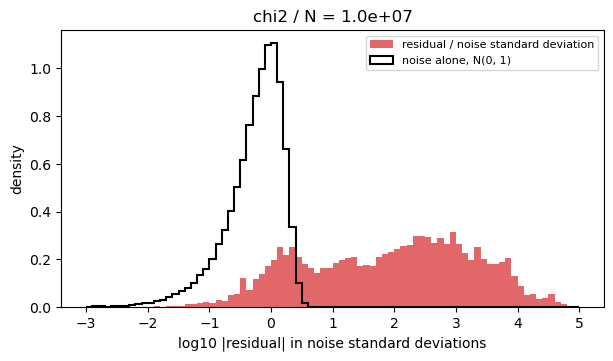

In [9]:
sample_sigma_m = np.sqrt(np.concatenate([np.diag(block) for block in noise_covariance.covariance_matrix_arrays]))
bins = np.linspace(-3, 5, 81)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(np.log10(np.abs(residual / sample_sigma_m)), bins=bins, density=True, color="C3", alpha=0.7,
        label="residual / noise standard deviation")
ax.hist(np.log10(np.abs(np.random.default_rng(1).standard_normal(100000))), bins=bins, density=True,
        histtype="step", color="k", lw=1.5, label="noise alone, N(0, 1)")
ax.set(xlabel="log10 |residual| in noise standard deviations", ylabel="density",
       title=f"chi2 / N = {-2 * noise_covariance.compute_loss(residual) / observed.size:.1e}")
ax.legend(fontsize=8)
plt.show()

## Synthetics as a `Stream`, over the data

The posterior-mean synthetics come back as an ObsPy `Stream` on the same time base as the data, ready for any
ObsPy tool. The figure draws them over the data, with the stations ordered by azimuth.

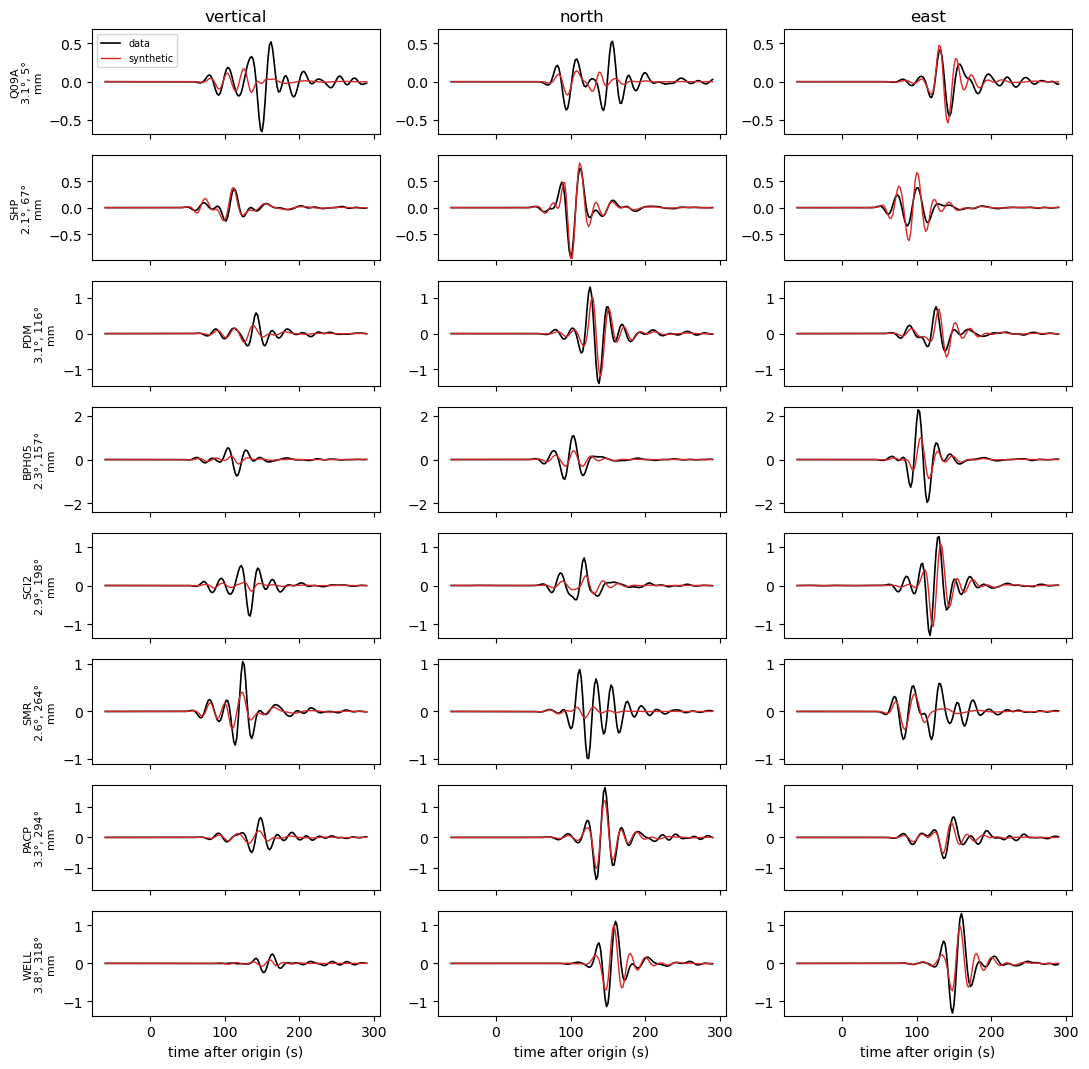

In [10]:
from seismo_sbi.simulators.synthetic_stream import seismogram_map_to_stream

synthetics = seismogram_map_to_stream(simulator.run_simulation(
    {"source_location": list(sources["GCMT centroid"]), "moment_tensor": list(posterior_mean)})[1],
    simulator, hypocentre.time)
data = processed.slice(*window)
order = sorted(geometry, key=lambda station: geometry[station][1])
fig, axes = plt.subplots(len(order), 3, figsize=(11, 1.35 * len(order)), sharex=True)
for row, station in zip(axes, order):
    scale_mm = 1.05e3 * max(np.abs(trace.data).max() for trace in data.select(station=station))
    for ax, component in zip(row, "ZNE"):
        for stream, style in ((data, dict(color="k", lw=1.2, label="data")),
                              (synthetics, dict(color="C3", lw=1.0, label="synthetic"))):
            trace = stream.select(station=station, component=component)[0]
            ax.plot(trace.times() + (trace.stats.starttime - hypocentre.time), trace.data * 1e3, **style)
        ax.set_ylim(-scale_mm, scale_mm)
    distance_m, azimuth_deg = geometry[station]
    row[0].set_ylabel(f"{station}\n{distance_m / 111.19e3:.1f}°, {azimuth_deg:.0f}°\nmm", fontsize=8)
for ax, component in zip(axes[0], "ZNE"):
    ax.set_title({"Z": "vertical", "N": "north", "E": "east"}[component])
for ax in axes[-1]:
    ax.set_xlabel("time after origin (s)")
axes[0, 0].legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

## The posterior as QuakeML, and the published tensors

`posterior_event` reports the posterior as an ObsPy `Event`: the mean tensor with each component's posterior
standard deviation, the scalar moment, the double-couple, CLVD and isotropic fractions, the nodal planes, the
principal axes and Mw. It is a point estimate with marginal spreads. Correlations between components and the
posterior's shape on the lune are not carried. The next cell writes the event next to the catalogue event, reads
the file back, and compares the fitted tensor with every published tensor by Kagan angle (the smallest rotation
that maps one double couple onto the other).

In [11]:
from obspy import Catalog

from seismo_sbi.moment_tensor.comparison import kagan
from seismo_sbi.moment_tensor.quakeml import posterior_event

posterior = posterior_event(posterior_samples, centroids[next(l for l in centroids if l.startswith("GCMT"))])
Catalog([catalogue[0], posterior]).write("ridgecrest_with_posterior.xml", format="QUAKEML")
written = read_events("ridgecrest_with_posterior.xml")
mechanism = written[1].preferred_focal_mechanism()
ours = moment_tensor_from_tensor(mechanism.moment_tensor.tensor)
planes = [mechanism.nodal_planes.nodal_plane_1, mechanism.nodal_planes.nodal_plane_2]
print(f"this posterior: Mw {written[1].preferred_magnitude().mag:.2f}, double couple "
      f"{100 * mechanism.moment_tensor.double_couple:.0f} %, nodal planes (strike/dip/rake) "
      + " and ".join(f"{plane.strike:.0f}/{plane.dip:.0f}/{plane.rake:.0f}" for plane in planes))
for label, m6 in published.items():
    print(f"{label:16s} Kagan angle to this posterior's mean {kagan(ours, m6):5.1f} deg")

this posterior: Mw 6.24, double couple 64 %, nodal planes (strike/dip/rake) 310/84/-174 and 219/84/-6
SCSN Mw 6.39     Kagan angle to this posterior's mean  21.5 deg
USGS Mw 6.47     Kagan angle to this posterior's mean   9.5 deg
USGS Mw 6.32     Kagan angle to this posterior's mean  11.7 deg
GCMT Mw 6.45     Kagan angle to this posterior's mean  12.0 deg
GFZ Mw 6.41      Kagan angle to this posterior's mean   7.4 deg


The fitted mechanism lies within 7 to 22 degrees of every published tensor. Its moment magnitude, 6.24, is below
the published 6.32 to 6.47. Its posterior, built on the noise covariance alone, is far narrower than the spread
between the agencies.

The next cell draws the source types on the lune: the posterior (red) against the published tensors. At
$\chi^2/N \approx 10^7$ the Gaussian-likelihood posterior is a point at this scale, so the lune carries the
comparison and no corner plot is drawn. The published tensors are deviatoric ($\delta = 0$) and lie between
$\gamma = -4°$ and $+7°$, around the double couple. This posterior sits 22 degrees above them, an isotropic part
that the published inversions exclude by construction. With a misfit this far above the noise, that part is more
likely modelling error than source.

this posterior's mean on the lune: gamma -4.2 deg, delta 22.1 deg


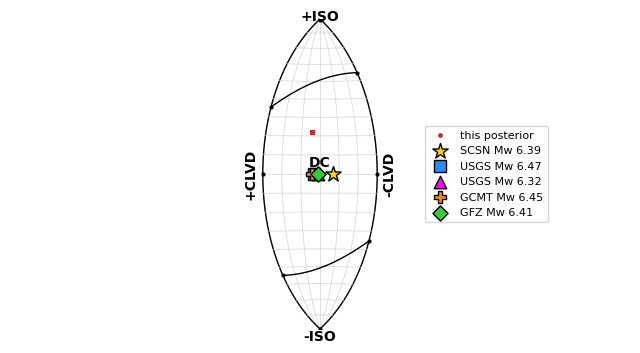

In [12]:
from seismo_sbi.moment_tensor.lune_angles import mts6_to_gamma_delta
from seismo_sbi.plotting.distributions import LUNE_REFERENCE_STYLES
from seismo_sbi.plotting.lune import plot_lune_frame, plot_scatter_on_lune

gamma_deg, delta_deg = mts6_to_gamma_delta(posterior_mean[None])
print(f"this posterior's mean on the lune: gamma {gamma_deg[0]:.1f} deg, delta {delta_deg[0]:.1f} deg")
fig, ax = plt.subplots(figsize=(8, 7))
lune = plot_lune_frame(ax)
plot_scatter_on_lune(ax, lune, *mts6_to_gamma_delta(posterior_samples[:500]), color="C3", s=6, label="this posterior", zorder=11)
for order, ((label, m6), style) in enumerate(zip(published.items(), LUNE_REFERENCE_STYLES)):
    plot_scatter_on_lune(ax, lune, *mts6_to_gamma_delta(m6[None]), marker=style["marker"], s=0.35 * style["s"],
                         facecolor=style["color"], edgecolor="k", label=label, zorder=12 + order)
ax.legend(loc="center left", bbox_to_anchor=(0.66, 0.5), fontsize=8)
plt.show()